# 4. LLM - Mental-Roberta

## 4.1. Loading the data

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
df = pd.read_csv("./data/circumplex_post_level.csv")
cols = ['user_id','timestamp','week','clean_text','valence_w','arousal_w','radius_w']
MIN_TOKENS = 5
RANDOM_STATE = 42

ro_df = df[cols].dropna().reset_index(drop=True)
ro_df['clean_text'] = ro_df['clean_text'].astype(str).str.strip()
ro_df['token_count'] = ro_df['clean_text'].apply(lambda x: len(x.split()))

def tok_count(s): 
    return len(s.split())
ro_df = ro_df[ro_df['clean_text'].map(tok_count) >= MIN_TOKENS].reset_index(drop=True)

In [3]:
df.shape

(42384, 44)

In [4]:
ro_df.head() 

,user_id,timestamp,clean_text,valence_w,arousal_w,radius_w,token_count
0,5925,2019-01-06,hello first post ive reading forum background ...,-0.626686,-0.287511,0.689491,124
1,1006,2019-01-06,dear catladyintraining welcome imagine number ...,0.074464,-0.243637,0.254762,181
2,1442,2019-01-07,dear catladyintraining first want welcome foru...,0.177682,0.342726,0.386047,190
3,2863,2019-01-07,catladyintraining welcome forum croix mary giv...,-0.739156,0.470644,0.876274,128
4,6342,2019-01-08,last pregnancy deal series traumatic event rea...,-0.345979,-0.105325,0.361655,205


In [5]:
ro_df.describe()

,user_id,valence_w,arousal_w,radius_w,token_count
count,41632.000000,41632.000000,41632.000000,41632.000000,41632.000000
mean,2515.585439,-0.026374,-0.020770,1.110157,88.030049
std,1831.314890,0.972279,0.972377,0.812091,64.206608
min,1001.000000,-2.977192,-3.299386,0.002359,5.000000
25%,1048.000000,-0.579239,-0.511823,0.557925,38.000000
50%,1577.000000,-0.195717,0.095927,0.881415,72.000000
75%,3574.250000,0.312764,0.576911,1.376860,122.000000
max,7320.000000,5.015376,4.296788,5.244921,413.000000


In [6]:
ro_df.shape

(41632, 7)

We removed the token < 5 text from the dataset to prevent the outlier

In [7]:
users = ro_df['user_id'].dropna().unique()
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(users)

n_users = len(users)
n_test = int(round(0.15 * n_users))
n_trainval = n_users - n_test
n_val = int(round(0.10 * n_trainval))
n_train = n_trainval - n_val

test_users = set(users[:n_test])
val_users  = set(users[n_test:n_test+n_val])
train_users= set(users[n_test+n_val:])

assert len(train_users & val_users) == 0
assert len(train_users & test_users) == 0
assert len(val_users & test_users) == 0

train_df = df[df['user_id'].isin(train_users)].reset_index(drop=True)
val_df   = df[df['user_id'].isin(val_users)].reset_index(drop=True)
test_df  = df[df['user_id'].isin(test_users)].reset_index(drop=True)

In [ ]:
def describe_split(name, d):
    stats = {
        "rows": len(d),
        "users": d['user_id'].nunique(),
        "v_mean": float(d['valence_w'].mean()),
        "v_std": float(d['valence_w'].std()),
        "a_mean": float(d['arousal_w'].mean()),
        "a_std": float(d['arousal_w'].std()),
    }
    # how coupled V/A are
    if len(d) > 2:
        try:
            r,_ = pearsonr(d['valence_w'], d['arousal_w'])
            stats["pearson_v_a"] = float(r)
        except Exception:
            stats["pearson_v_a"] = None
    return name, stats

for name, stats in map(lambda x: describe_split(*x), 
                       [("train", train_df), ("val", val_df), ("test", test_df)]):
    print(name, stats)


train {'rows': 33898, 'users': 4791, 'v_mean': -0.008616877691431431, 'v_std': 0.9800743340533249, 'a_mean': -0.007744072049700993, 'a_std': 0.9813118054204975, 'pearson_v_a': None}
val {'rows': 2125, 'users': 532, 'v_mean': -0.029035820627775474, 'v_std': 1.0287925927998802, 'a_mean': 0.051982475439055244, 'a_std': 1.0221161050464613, 'pearson_v_a': None}
test {'rows': 6305, 'users': 939, 'v_mean': 0.04896307334401036, 'v_std': 1.0835608919377628, 'a_mean': 0.01722771941662833, 'a_std': 1.0761503580024996, 'pearson_v_a': None}


In [9]:
v_pred = train_df['valence_w'].mean()
a_pred = train_df['arousal_w'].mean()

def mae(y, yhat): 
    return float(np.mean(np.abs(y - yhat)))

baseline = {
    "val_MAE_valence": mae(val_df['valence_w'], v_pred),
    "val_MAE_arousal": mae(val_df['arousal_w'], a_pred),
    "test_MAE_valence": mae(test_df['valence_w'], v_pred),
    "test_MAE_arousal": mae(test_df['arousal_w'], a_pred),
}
print("naive_baseline", baseline)

naive_baseline {'val_MAE_valence': 0.7414564707716723, 'val_MAE_arousal': 0.7794073695707413, 'test_MAE_valence': 0.7740338262544293, 'test_MAE_arousal': 0.8168782105997874}


## 4.2. Tokenizer

In [10]:
os.environ["USE_TF"] = "0"
os.environ["USE_JAX"] = "0"
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoModel
from transformers import DataCollatorWithPadding
import evaluate

In [ ]:
MODEL_NAME = "mental/mental-roberta-base"
MAX_LEN = 256
BATCH = 32
USE_CLS    = False

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

class TextOnlyDS(Dataset):
    def __init__(self, texts): self.texts = texts
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        return tok(
            self.texts[i],
            truncation=True,
            max_length=MAX_LEN,
            padding=False,
            return_attention_mask=True,
        )

def collate(batch):
    return tok.pad(
        batch,
        padding=True,
        return_tensors="pt"
    )

@torch.no_grad()
def encode_texts(texts, batch_size=BATCH, use_cls=USE_CLS):
    ds = TextOnlyDS(texts)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate)
    chunks = []

    # autocast only on CUDA
    use_amp = (device.type == "cuda")
    if use_amp:
        from torch.cuda.amp import autocast

    for enc in dl:
        enc = {k: v.to(device) for k, v in enc.items()}
        if use_amp:
            with autocast():
                out = model(**enc)  
        else:
            out = model(**enc)

        hidden = out.last_hidden_state                   # (B, T, H)
        if use_cls:
            emb = hidden[:, 0, :]                        # CLS
        else:
            # mean-pool over valid tokens
            mask = enc["attention_mask"].unsqueeze(-1)   # (B, T, 1)
            summed = (hidden * mask).sum(dim=1)          # (B, H)
            counts = mask.sum(dim=1).clamp(min=1)        # (B, 1)
            emb = summed / counts                        # (B, H)

        chunks.append(emb.cpu())

    return torch.cat(chunks, dim=0).numpy() 

texts_train = train_df["clean_text"].tolist()
texts_val   = val_df["clean_text"].tolist()
texts_test  = test_df["clean_text"].tolist()

X_train = encode_texts(texts_train)
X_val   = encode_texts(texts_val)
X_test  = encode_texts(texts_test)

print("Embeddings:", X_train.shape, X_val.shape, X_test.shape)

Y_train = train_df[["valence_w","arousal_w"]].to_numpy(dtype=np.float32)
Y_val   = val_df[["valence_w","arousal_w"]].to_numpy(dtype=np.float32)
Y_test  = test_df[["valence_w","arousal_w"]].to_numpy(dtype=np.float32)


Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Embeddings: (33898, 768) (2125, 768) (6305, 768)


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from scipy.stats import linregress, pearsonr, spearmanr
import math, time, itertools, random
import torch.nn as nn
import torch, torch.nn as nn, torch.optim as optim

In [17]:
def eval_va(y_true, y_pred):
    v_mae = mean_absolute_error(y_true[:,0], y_pred[:,0])
    a_mae = mean_absolute_error(y_true[:,1], y_pred[:,1])
    def r(x, y):
        return pearsonr(x, y)[0] if len(x) > 2 else np.nan
    return {
        "mae_valence": v_mae,
        "mae_arousal": a_mae,
        "r_valence": r(y_true[:,0], y_pred[:,0]),
        "r_arousal": r(y_true[:,1], y_pred[:,1]),
    }
    
scaler = StandardScaler(with_mean=True, with_std=True)
Xtr = scaler.fit_transform(X_train)
Xva = scaler.transform(X_val)
Xte = scaler.transform(X_test)

alphas = np.logspace(-2, 3, 1000) 
rv = RidgeCV(alphas=alphas)
ra = RidgeCV(alphas=alphas)

rv.fit(Xtr, Y_train[:,0])
ra.fit(Xtr, Y_train[:,1])

print(f"Chosen alpha (valence): {rv.alpha_:.4g}")
print(f"Chosen alpha (arousal): {ra.alpha_:.4g}")

pred_val = np.column_stack([rv.predict(Xva), ra.predict(Xva)])
pred_test= np.column_stack([rv.predict(Xte), ra.predict(Xte)])

val_metrics  = eval_va(Y_val,  pred_val)
test_metrics = eval_va(Y_test, pred_test)

print("\nVAL:",  val_metrics)
print("TEST:", test_metrics)

Chosen alpha (valence): 595.4
Chosen alpha (arousal): 668.1

VAL: {'mae_valence': 0.5321421494043517, 'mae_arousal': 0.5500408411630848, 'r_valence': 0.6424519528487661, 'r_arousal': 0.6475976949347038}
TEST: {'mae_valence': 0.5682641626712055, 'mae_arousal': 0.6007090064268916, 'r_valence': 0.6373331022869922, 'r_arousal': 0.6015650934193963}


In [22]:
def eval_va(y_true, y_pred):
    v_mae = mean_absolute_error(y_true[:,0], y_pred[:,0])
    a_mae = mean_absolute_error(y_true[:,1], y_pred[:,1])
    r = lambda x,y: pearsonr(x,y)[0]
    return {"mae_valence": v_mae, "mae_arousal": a_mae,
            "r_valence": r(y_true[:,0], y_pred[:,0]),
            "r_arousal": r(y_true[:,1], y_pred[:,1])}

class MLP(nn.Module):
    def __init__(self, d, h=512, p=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,h), nn.ReLU(), nn.Dropout(p),
            nn.Linear(h,2)
        )
    def forward(self,x): return self.net(x)

device = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))

Xtr = torch.from_numpy(X_train).float().to(device)
Ytr = torch.from_numpy(Y_train).float().to(device)
Xva = torch.from_numpy(X_val  ).float().to(device)
Yva = torch.from_numpy(Y_val  ).float().to(device)

model = MLP(Xtr.shape[1], h=512, p=0.05).to(device)
opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
lossf = nn.SmoothL1Loss()

best = {"epoch": None, "mae_sum": 1e9, "state_dict": None, "val_metrics": None}
for ep in range(10):
    model.train()
    idx = torch.randperm(Xtr.size(0), device=device)
    for i in range(0, Xtr.size(0), 256):
        b = idx[i:i+256]
        opt.zero_grad()
        loss = lossf(model(Xtr[b]), Ytr[b])
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xva).cpu().numpy()
    m = eval_va(Y_val, pred)
    mae_sum = m["mae_valence"] + m["mae_arousal"]
    print(f"epoch {ep+1}", m, " | mae_sum:", mae_sum)

    if mae_sum < best["mae_sum"]:
        best.update({
            "epoch": ep+1,
            "mae_sum": mae_sum,
            "val": m,
            "state_dict": {k:v.cpu().clone() for k,v in model.state_dict().items()},
            "val_metrics": m
        })

print("\nBest epoch:", best["epoch"], "val:", best["val_metrics"])

model.load_state_dict(best["state_dict"])
model.eval()
with torch.no_grad():
    pred_test = model(torch.from_numpy(X_test).float().to(device)).cpu().numpy()
test_metrics = eval_va(Y_test, pred_test)
print("TEST:", test_metrics)

epoch 1 {'mae_valence': 0.5298393964767456, 'mae_arousal': 0.5352117419242859, 'r_valence': 0.6297986026061845, 'r_arousal': 0.6500973409081512}  | mae_sum: 1.0650511384010315
epoch 2 {'mae_valence': 0.5184397101402283, 'mae_arousal': 0.5142502188682556, 'r_valence': 0.6539508189381739, 'r_arousal': 0.6721855700108101}  | mae_sum: 1.0326899290084839
epoch 3 {'mae_valence': 0.5107230544090271, 'mae_arousal': 0.5038047432899475, 'r_valence': 0.6587727377359128, 'r_arousal': 0.6834519042951329}  | mae_sum: 1.0145277976989746
epoch 4 {'mae_valence': 0.5083484053611755, 'mae_arousal': 0.5027319192886353, 'r_valence': 0.6675429877421274, 'r_arousal': 0.6834940022763661}  | mae_sum: 1.0110803246498108
epoch 5 {'mae_valence': 0.5143879055976868, 'mae_arousal': 0.49546635150909424, 'r_valence': 0.6720636273385663, 'r_arousal': 0.6919276705792734}  | mae_sum: 1.009854257106781
epoch 6 {'mae_valence': 0.4963068664073944, 'mae_arousal': 0.5008701086044312, 'r_valence': 0.6768077064538743, 'r_arous

In [ ]:
device = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print("Using device:", device)

def to_t(x): 
    return torch.from_numpy(x).float().to(device)

def eval_va(y_true, y_pred):
    v_mae = mean_absolute_error(y_true[:,0], y_pred[:,0])
    a_mae = mean_absolute_error(y_true[:,1], y_pred[:,1])
    def r(x, y):
        if len(x) < 3: return np.nan
        return pearsonr(x, y)[0]
    return {
        "mae_valence": v_mae,
        "mae_arousal": a_mae,
        "r_valence": r(y_true[:,0], y_pred[:,0]),
        "r_arousal": r(y_true[:,1], y_pred[:,1]),
        "mae_sum": v_mae + a_mae
    }

class MLP(nn.Module):
    def __init__(self, d, h=512, p=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, h), nn.ReLU(), nn.Dropout(p),
            nn.Linear(h, 2)
        )
    def forward(self, x): return self.net(x)

def to_t(x): return torch.from_numpy(x).float().to(device)
Xtr = to_t(X_train);  Ytr = to_t(Y_train)
Xva = to_t(X_val);    Yva = to_t(Y_val)
Xte = to_t(X_test);   Yte = to_t(Y_test)

def run_one(h=512, p=0.10, lr=1e-3, wd=0.01, loss_name="huber",
            epochs=12, batch=256, patience=2, seed=42):
    # small helper to run one MLP config
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    model = MLP(Xtr.shape[1], h=h, p=p).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.SmoothL1Loss() if loss_name == "huber" else nn.MSELoss()

    best = {"epoch": None, "mae_sum": float("inf"), "state": None, "val": None}
    no_improve = 0

    for ep in range(1, epochs+1):
        model.train()
        idx = torch.randperm(Xtr.size(0), device=device)
        for i in range(0, Xtr.size(0), batch):
            b = idx[i:i+batch]
            opt.zero_grad(set_to_none=True)
            pred = model(Xtr[b])
            loss = lossf(pred, Ytr[b])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            pred_val = model(Xva).cpu().numpy()
        m = eval_va(Y_val, pred_val)

        if m["mae_sum"] < best["mae_sum"] - 1e-5:
            best.update(epoch=ep, mae_sum=m["mae_sum"],
                        state={k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                        val=m)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve > patience:
                break

    # test with best weights
    model.load_state_dict(best["state"])
    model.eval()
    with torch.no_grad():
        pred_test = model(Xte).cpu().numpy()
    test_metrics = eval_va(Y_test, pred_test)

    return best["val"], test_metrics, {"h":h, "p":p, "lr":lr, "wd":wd, "loss":loss_name, "epochs":best["epoch"]}

H = [384, 512, 768]
P = [0.05, 0.10, 0.15]
LR = [1e-3, 5e-4]
WD = [0.0, 0.01]
LOSS = ["huber", "mse"]
EPOCHS = 12
BATCH = 256
PATIENCE = 3

results = []
t0 = time.time()
for h, p, lr, wd, loss_name in itertools.product(H, P, LR, WD, LOSS):
    val_m, test_m, cfg = run_one(h=h, p=p, lr=lr, wd=wd, loss_name=loss_name,
                                 epochs=EPOCHS, batch=BATCH, patience=PATIENCE, seed=42)
    results.append((cfg, val_m, test_m))
    print(f"[DONE] {cfg}  VAL mae_sum={val_m['mae_sum']:.4f}  TEST mae_sum={test_m['mae_sum']:.4f}")

print(f"\nTook {time.time()-t0:.1f}s for {len(results)} runs.")

# top-5
results_sorted = sorted(results, key=lambda x: x[1]["mae_sum"])
print("\nTop 5 configs (by VAL mae_sum):")
for i, (cfg, val_m, test_m) in enumerate(results_sorted[:5], 1):
    print(f"{i}. cfg={cfg}  VAL={val_m}  TEST={test_m}")


Using device: mps
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.001, 'wd': 0.0, 'loss': 'huber', 'epochs': 9}  VAL mae_sum=0.9792  TEST mae_sum=1.0722
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.001, 'wd': 0.0, 'loss': 'mse', 'epochs': 10}  VAL mae_sum=0.9855  TEST mae_sum=1.0813
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.001, 'wd': 0.01, 'loss': 'huber', 'epochs': 9}  VAL mae_sum=0.9794  TEST mae_sum=1.0731
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.001, 'wd': 0.01, 'loss': 'mse', 'epochs': 10}  VAL mae_sum=0.9848  TEST mae_sum=1.0827
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.0005, 'wd': 0.0, 'loss': 'huber', 'epochs': 12}  VAL mae_sum=0.9840  TEST mae_sum=1.0744
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.0005, 'wd': 0.0, 'loss': 'mse', 'epochs': 10}  VAL mae_sum=1.0004  TEST mae_sum=1.0900
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.0005, 'wd': 0.01, 'loss': 'huber', 'epochs': 12}  VAL mae_sum=0.9853  TEST mae_sum=1.0748
[DONE] {'h': 384, 'p': 0.05, 'lr': 0.0005, 'wd': 0.01, 'loss': 'mse', 'epochs': 10}  VAL mae_sum=1.0023  TEST

In [26]:
seeds = [41, 42, 43]
best_runs = []
for sd in seeds:
    val_m, test_m, cfg = run_one(h=512, p=0.05, lr=1e-3, wd=0.0,
                                 loss_name="huber", epochs=12, batch=256,
                                 patience=3, seed=sd)
    best_runs.append((sd, val_m, test_m))
    print(f"seed={sd}  VAL mae_sum={val_m['mae_sum']:.4f}  TEST mae_sum={test_m['mae_sum']:.4f}")

# Pick the median-by-VAL run (or best TEST if you prefer)
best_runs.sort(key=lambda x: x[1]["mae_sum"])
print("\nSummary:")
for r in best_runs: print(r)

seed=41  VAL mae_sum=0.9712  TEST mae_sum=1.0656
seed=42  VAL mae_sum=0.9748  TEST mae_sum=1.0711
seed=43  VAL mae_sum=0.9761  TEST mae_sum=1.0704

Summary:
(41, {'mae_valence': 0.4882754385471344, 'mae_arousal': 0.4828996956348419, 'r_valence': 0.6825617902649489, 'r_arousal': 0.7046741142408096, 'mae_sum': 0.9711751341819763}, {'mae_valence': 0.5322669148445129, 'mae_arousal': 0.5333731770515442, 'r_valence': 0.6626883535556662, 'r_arousal': 0.6590635079334913, 'mae_sum': 1.0656400918960571})
(42, {'mae_valence': 0.4879249334335327, 'mae_arousal': 0.48683908581733704, 'r_valence': 0.6853412477299877, 'r_arousal': 0.7017812752122318, 'mae_sum': 0.9747640192508698}, {'mae_valence': 0.533018946647644, 'mae_arousal': 0.5380694270133972, 'r_valence': 0.6590219223919005, 'r_arousal': 0.6563546086662119, 'mae_sum': 1.0710883736610413})
(43, {'mae_valence': 0.492200642824173, 'mae_arousal': 0.4838967025279999, 'r_valence': 0.6840974699235388, 'r_arousal': 0.7068734889238434, 'mae_sum': 0.976

Until now, the best thredsholds: h=512, dropout=0.05, lr=1e-3, wd=0.0,seed=41
After we found the best parameter, we apply to our pipeline and we will use py file in the future.

In [1]:
from mental_roberta import run_llm_pipeline
outs = run_llm_pipeline("./data/circumplex_post_level.csv")

Using device: mps


Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Ridge VAL : {'mae_valence': 0.5334626118707168, 'mae_arousal': 0.544869758405413, 'r_valence': 0.6108317869509623, 'r_arousal': 0.6229176961627095, 'rho_valence': 0.6183911616632296, 'rho_arousal': 0.6787351061033563, 'mae_sum': 1.0783323702761298}
Ridge TEST: {'mae_valence': 0.5587753278103584, 'mae_arousal': 0.5822627233781995, 'r_valence': 0.6143575162994017, 'r_arousal': 0.5875119463678775, 'rho_valence': 0.6162800821646524, 'rho_arousal': 0.6572452551930961, 'mae_sum': 1.1410380511885578}
MLP VAL  : {'mae_valence': 0.49143049120903015, 'mae_arousal': 0.4860900938510895, 'r_valence': 0.6592817756475897, 'r_arousal': 0.6780903874413653, 'rho_valence': 0.6438906219760999, 'rho_arousal': 0.7134818939669616, 'mae_sum': 0.9775205850601196}
MLP TEST : {'mae_valence': 0.529549241065979, 'mae_arousal': 0.5235807299613953, 'r_valence': 0.6333943337534533, 'r_arousal': 0.6394227033551972, 'rho_valence': 0.6400601304660827, 'rho_arousal': 0.6929317156717714, 'mae_sum': 1.0531299710273743}
Cal

In [6]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr, spearmanr

def metrics(y_true, y_pred):
    vt, at = y_true[:,0], y_true[:,1]
    vp, ap = y_pred[:,0], y_pred[:,1]
    out = {
        "mae_valence": mean_absolute_error(vt, vp),
        "mae_arousal": mean_absolute_error(at, ap),
        "r_valence": pearsonr(vt, vp)[0],
        "r_arousal": pearsonr(at, ap)[0],
        "rho_valence": spearmanr(vt, vp).correlation,
        "rho_arousal": spearmanr(at, ap).correlation,
    }
    out["mae_sum"] = out["mae_valence"] + out["mae_arousal"]
    return out

summary = pd.DataFrame(
    {"VAL": metrics(outs.Y_val, outs.Y_val_pred),
     "TEST": metrics(outs.Y_test, outs.Y_test_pred)}
).T
summary

,mae_valence,mae_arousal,r_valence,r_arousal,rho_valence,rho_arousal,mae_sum
VAL,0.491430,0.486090,0.659282,0.678090,0.643891,0.713482,0.977521
TEST,0.529549,0.523581,0.633394,0.639423,0.640060,0.692932,1.053130


VAL and TEST are quite close, so the model seems to generalise okay.

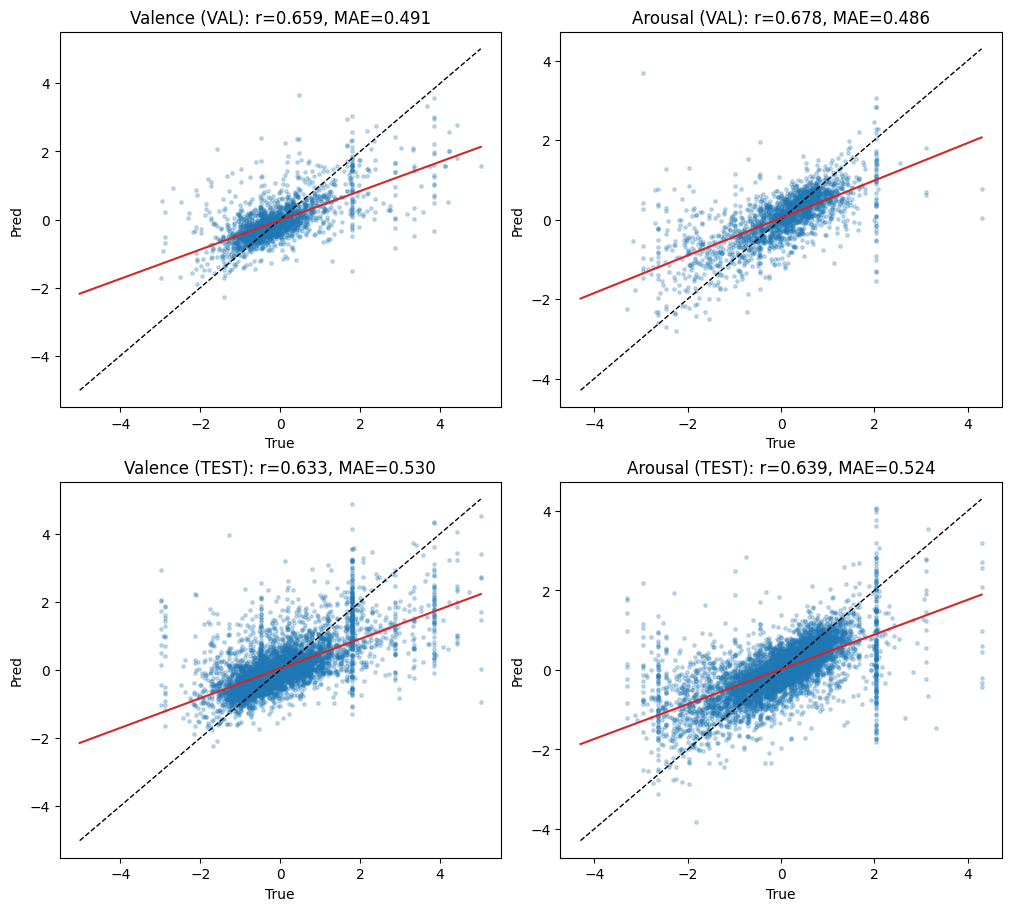

In [7]:
from scipy.stats import linregress

def scatter_with_identity(y_true, y_pred, axis_name, ax):
    ax.scatter(y_true, y_pred, s=6, alpha=0.25)
    # identity
    lim = max(abs(y_true).max(), abs(y_pred).max(), 3)
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
    # linear fit pred ~ true (for visual)
    lr = linregress(y_true, y_pred)
    xs = np.linspace(-lim, lim, 100)
    ax.plot(xs, lr.slope*xs + lr.intercept, color='C3', lw=1.5)
    ax.set_title(f'{axis_name}: r={pearsonr(y_true,y_pred)[0]:.3f}, MAE={mean_absolute_error(y_true,y_pred):.3f}')
    ax.set_xlabel('True')
    ax.set_ylabel('Pred')

fig, axes = plt.subplots(2,2, figsize=(10,9), constrained_layout=True)
scatter_with_identity(outs.Y_val[:,0], outs.Y_val_pred[:,0], "Valence (VAL)", axes[0,0])
scatter_with_identity(outs.Y_val[:,1], outs.Y_val_pred[:,1], "Arousal (VAL)", axes[0,1])
scatter_with_identity(outs.Y_test[:,0], outs.Y_test_pred[:,0], "Valence (TEST)", axes[1,0])
scatter_with_identity(outs.Y_test[:,1], outs.Y_test_pred[:,1], "Arousal (TEST)", axes[1,1])
plt.show()

Most points sit around the diagonal. The fitted line is flatter than 1 (slope < 1), and we can see some vertical stripes near the extreme values.

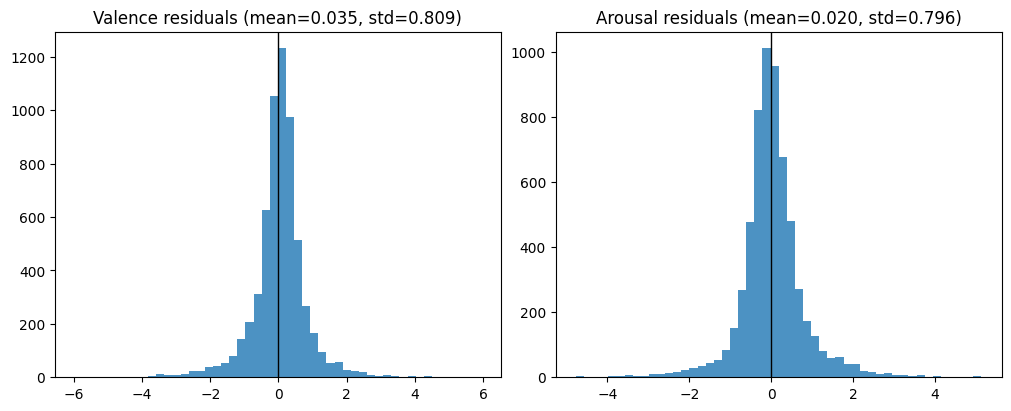

In [8]:
def residuals(y_true, y_pred):
    return y_pred - y_true  # signed error

import matplotlib.pyplot as plt
rv = residuals(outs.Y_test[:,0], outs.Y_test_pred[:,0])
ra = residuals(outs.Y_test[:,1], outs.Y_test_pred[:,1])

fig, ax = plt.subplots(1,2, figsize=(10,4), constrained_layout=True)
ax[0].hist(rv, bins=50, alpha=0.8)
ax[0].set_title(f'Valence residuals (mean={rv.mean():.3f}, std={rv.std():.3f})')
ax[0].axvline(0, color='k', lw=1)

ax[1].hist(ra, bins=50, alpha=0.8)
ax[1].set_title(f'Arousal residuals (mean={ra.mean():.3f}, std={ra.std():.3f})')
ax[1].axvline(0, color='k', lw=1)
plt.show()

Predictions are centered but not wide enough. Means are near zero (+0.035 V, +0.020 A) means minimal bias.

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_95297/1763408308.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  len_table = df_err.groupby("bucket")[["mae_v","mae_a"]].mean().reset_index()


,bucket,mae_v,mae_a
0,short (≤20),1.003379,1.045552
1,medium (21–60),0.597897,0.597005
2,long (≥61),0.353420,0.330761


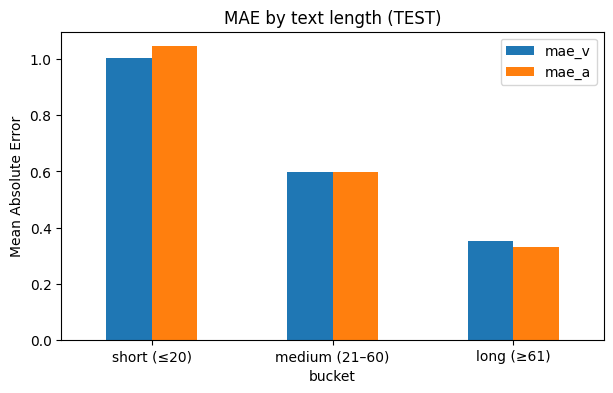

In [9]:
test_len = outs.test_df["clean_text"].astype(str).str.split().apply(len).to_numpy()
bins = [0, 20, 60, 10_000]
labels = ["short (≤20)", "medium (21–60)", "long (≥61)"]
cats = pd.cut(test_len, bins=bins, labels=labels, right=True, include_lowest=True)

df_err = pd.DataFrame({
    "bucket": cats,
    "mae_v": np.abs(outs.Y_test_pred[:,0] - outs.Y_test[:,0]),
    "mae_a": np.abs(outs.Y_test_pred[:,1] - outs.Y_test[:,1]),
})
len_table = df_err.groupby("bucket")[["mae_v","mae_a"]].mean().reset_index()
display(len_table)

ax = len_table.set_index("bucket").plot(kind="bar", figsize=(7,4))
ax.set_ylabel("Mean Absolute Error")
ax.set_title("MAE by text length (TEST)")
plt.xticks(rotation=0)
plt.show()

Longer posts clearly give better signal – short comments are pretty noisy so the model just predicts something near the mean. For weekly sequences we can add weight by token to avoid noise.

In [10]:
def quadrant(v, a):
    # Q1: (+V,+A), Q2: (-V,+A), Q3: (-V,-A), Q4: (+V,-A)
    return np.where((v>=0)&(a>=0), "Q1 +V,+A",
           np.where((v<0)&(a>=0), "Q2 -V,+A",
           np.where((v<0)&(a<0),  "Q3 -V,-A", "Q4 +V,-A")))

q_true = quadrant(outs.Y_test[:,0], outs.Y_test[:,1])
mae_v = np.abs(outs.Y_test_pred[:,0] - outs.Y_test[:,0])
mae_a = np.abs(outs.Y_test_pred[:,1] - outs.Y_test[:,1])

quad_tbl = pd.DataFrame({"quadrant": q_true, "mae_v": mae_v, "mae_a": mae_a}) \
            .groupby("quadrant")[["mae_v","mae_a"]].mean() \
            .sort_index()
display(quad_tbl)

,mae_v,mae_a
quadrant,,
"Q1 +V,+A",0.604134,0.608750
"Q2 -V,+A",0.358468,0.379126
"Q3 -V,-A",0.571239,0.608988
"Q4 +V,-A",0.709995,0.597346


Calm/positive posts seem more generic in wording, so the affective cues are weaker and the model tends to underestimate valence there. 

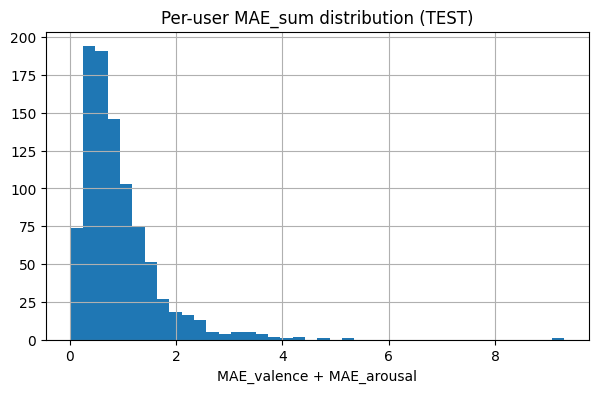

Worst users:
             mae_v     mae_a   mae_sum
user_id                              
7113     4.165330  5.127979  9.293308
2091     3.927057  1.351363  5.278420
2070     1.781050  3.004884  4.785934
5044     0.746827  3.637132  4.383959
5661     1.951669  2.348219  4.299889
6465     1.955524  2.215777  4.171301
1823     3.473699  0.427609  3.901307
4906     1.477238  2.331806  3.809044
3504     1.577627  2.064685  3.642312
3211     0.996397  2.621619  3.618016

Best users:
             mae_v     mae_a   mae_sum
user_id                              
4436     0.001819  0.016468  0.018287
2447     0.015857  0.009248  0.025105
6003     0.026557  0.014234  0.040791
4230     0.012608  0.032021  0.044629
2493     0.015983  0.029343  0.045326
1597     0.029266  0.031300  0.060566
7015     0.003483  0.066250  0.069734
2328     0.055542  0.023726  0.079268
4272     0.078182  0.003097  0.081279
5300     0.028972  0.055577  0.084549


In [11]:
test_users = outs.test_df["user_id"].to_numpy()
user_df = pd.DataFrame({
    "user_id": test_users,
    "mae_v": mae_v,
    "mae_a": mae_a,
})
user_mae = user_df.groupby("user_id")[["mae_v","mae_a"]].mean()
user_mae["mae_sum"] = user_mae["mae_v"] + user_mae["mae_a"]

ax = user_mae["mae_sum"].hist(bins=40, figsize=(7,4))
ax.set_title("Per-user MAE_sum distribution (TEST)")
ax.set_xlabel("MAE_valence + MAE_arousal")
plt.show()

worst = user_mae.sort_values("mae_sum", ascending=False).head(10)
best  = user_mae.sort_values("mae_sum", ascending=True).head(10)
print("Worst users:\n", worst)
print("\nBest users:\n", best)

For LSTM, we need to consider minimum weeks / minimum tokens per week thresholds or robust aggregation to control these tails.

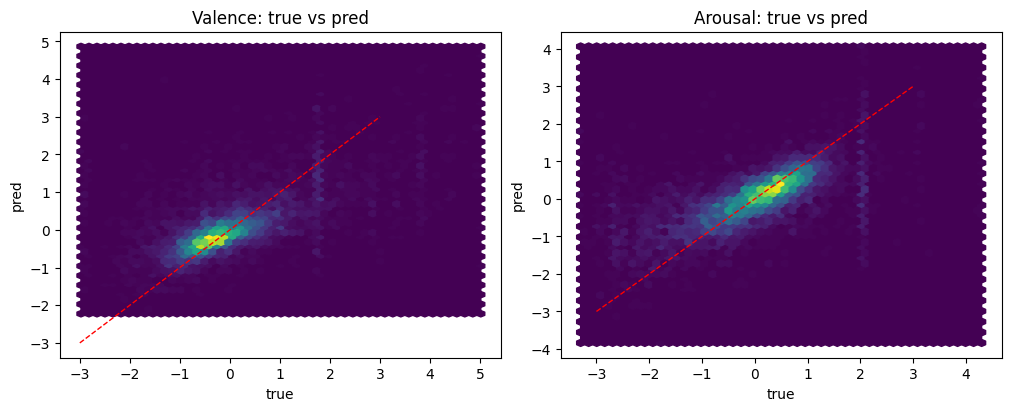

In [12]:
fig, ax = plt.subplots(1,2, figsize=(10,4), constrained_layout=True)
ax[0].hexbin(outs.Y_test[:,0], outs.Y_test_pred[:,0], gridsize=50, cmap="viridis")
ax[0].plot([-3,3],[-3,3],'r--',lw=1); ax[0].set_title("Valence: true vs pred"); ax[0].set_xlabel("true"); ax[0].set_ylabel("pred")

ax[1].hexbin(outs.Y_test[:,1], outs.Y_test_pred[:,1], gridsize=50, cmap="viridis")
ax[1].plot([-3,3],[-3,3],'r--',lw=1); ax[1].set_title("Arousal: true vs pred"); ax[1].set_xlabel("true"); ax[1].set_ylabel("pred")
plt.show()

Same under-dispersion sign. The central mass being tight is good—everyday affect is captured; extremes are tough.

- Mental-RoBERTa baseline is reasonably strong: TEST MAE ~0.53 (V) / 0.52 (A), r around 0.63–0.64.
- Main weak spots:
  - very short texts (model falls back to something near the mean),
  - calm/positive Q4 stuff,
  - and extreme values (ground truth is also clipped).
- For the next steps:
  - aggregate to weekly user level (probably token-weighted mean or median),
  - build an LSTM to predict next-week V/A,
  - and then add fusion features: weekly LLM outputs + Circumplex (valence_w, arousal_w, radius_w), and maybe some Empath.

In [17]:
from mental_roberta import load_posts_csv, predict_posts
all_df = load_posts_csv(CSV, min_tokens=5)
len(all_df), all_df.head(2)

(41632,
    user_id   timestamp                                         clean_text  \
 0     5925  2019-01-06  hello first post ive reading forum background ...   
 1     1006  2019-01-06  dear catladyintraining welcome imagine number ...   
 
    valence_w  arousal_w  radius_w  
 0  -0.626686  -0.287511  0.689491  
 1   0.074464  -0.243637  0.254762  )